In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import userdata
import os

token = userdata.get('GITHUB_TOKEN')
username = "Manoj-R27"
email = "pes2ug23cs328@pesu.pes.edu"
repo = "recsys-causal-rl"

!git config --global user.email "{email}"
!git config --global user.name "{username}"
os.chdir('/content')
!git clone https://{token}@github.com/{username}/{repo}.git
print("Repo cloned!")

Cloning into 'recsys-causal-rl'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 24 (delta 5), reused 19 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 228.23 KiB | 4.86 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Repo cloned!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q ml-100k.zip

ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                      names=['user_id','movie_id','rating','timestamp'])
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                     usecols=[0,1], names=['movie_id','title'])

user_movie_matrix = ratings.pivot_table(
    index='user_id', columns='movie_id', values='rating').fillna(0)

svd = TruncatedSVD(n_components=200, random_state=42)
matrix_svd = svd.fit_transform(user_movie_matrix)

print("Data and model loaded!")

Data and model loaded!


In [5]:
# Multi-Armed Bandit for recommendations
# Each movie = one arm of the bandit
# Reward = 1 if user likes the movie (rating >= 4), 0 otherwise

class MovieBandit:
    def __init__(self, ratings_df, n_movies):
        self.ratings_df = ratings_df
        self.n_movies = n_movies
        # True reward probability for each movie
        # Based on actual ratings in dataset
        self.true_rewards = {}
        for movie_id in ratings_df['movie_id'].unique():
            movie_ratings = ratings_df[ratings_df['movie_id'] == movie_id]['rating']
            self.true_rewards[movie_id] = (movie_ratings >= 4).mean()

    def get_reward(self, movie_id):
        # Simulate user clicking / liking a movie
        prob = self.true_rewards.get(movie_id, 0.1)
        return np.random.binomial(1, prob)

# Initialize bandit
movie_ids = ratings['movie_id'].unique()
bandit = MovieBandit(ratings, len(movie_ids))

print(f"Bandit initialized with {len(movie_ids)} movie arms!")
print(f"Example — Star Wars reward probability: {round(bandit.true_rewards.get(50, 0), 3)}")

Bandit initialized with 1682 movie arms!
Example — Star Wars reward probability: 0.859


In [6]:
class EpsilonGreedyAgent:
    def __init__(self, movie_ids, epsilon=0.1):
        self.epsilon = epsilon
        self.movie_ids = movie_ids
        # Track estimated reward for each movie
        self.q_values = {m: 0.0 for m in movie_ids}
        self.counts = {m: 0 for m in movie_ids}
        self.total_reward = 0
        self.rewards_history = []

    def select_movie(self):
        if np.random.random() < self.epsilon:
            # Explore — pick random movie
            return np.random.choice(self.movie_ids)
        else:
            # Exploit — pick best known movie
            return max(self.q_values, key=self.q_values.get)

    def update(self, movie_id, reward):
        self.counts[movie_id] += 1
        # Incremental average update
        n = self.counts[movie_id]
        self.q_values[movie_id] += (reward - self.q_values[movie_id]) / n
        self.total_reward += reward
        self.rewards_history.append(self.total_reward)

agent = EpsilonGreedyAgent(movie_ids, epsilon=0.1)
print("Epsilon-Greedy agent initialized!")
print(f"Epsilon: 0.1 — explores 10% of the time, exploits 90%")

Epsilon-Greedy agent initialized!
Epsilon: 0.1 — explores 10% of the time, exploits 90%


In [7]:
# Run bandit for 10000 steps
n_steps = 10000

print("Training bandit...")
for step in range(n_steps):
    # Agent selects a movie
    movie_id = agent.select_movie()
    # Environment gives reward
    reward = bandit.get_reward(movie_id)
    # Agent updates its knowledge
    agent.update(movie_id, reward)

    if (step + 1) % 2000 == 0:
        avg_reward = agent.total_reward / (step + 1)
        print(f"Step {step+1}: Average reward = {round(avg_reward, 3)}")

print(f"\nFinal average reward: {round(agent.total_reward/n_steps, 3)}")
print("Bandit training complete!")

Training bandit...
Step 2000: Average reward = 0.913
Step 4000: Average reward = 0.912
Step 6000: Average reward = 0.915
Step 8000: Average reward = 0.916
Step 10000: Average reward = 0.917

Final average reward: 0.917
Bandit training complete!


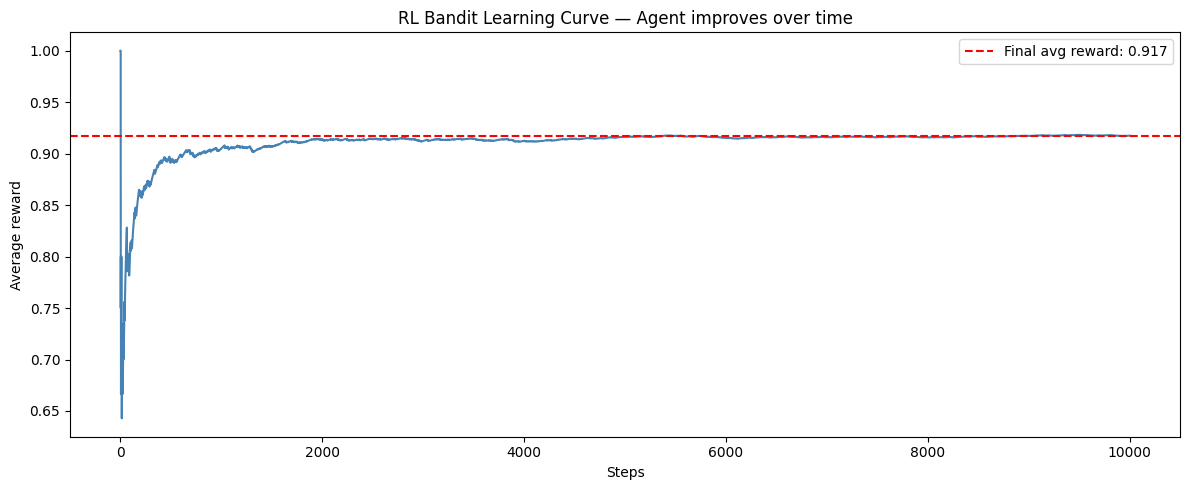

Agent started with reward: 0.812
Agent ended with reward:   0.917
Improvement: 13.0%


In [8]:
# Plot how the agent improves over time
cumulative_avg = [agent.rewards_history[i]/(i+1)
                  for i in range(len(agent.rewards_history))]

plt.figure(figsize=(12, 5))
plt.plot(cumulative_avg, color='steelblue', linewidth=1.5)
plt.axhline(y=cumulative_avg[-1], color='red', linestyle='--',
            label=f'Final avg reward: {round(cumulative_avg[-1], 3)}')
plt.xlabel('Steps')
plt.ylabel('Average reward')
plt.title('RL Bandit Learning Curve — Agent improves over time')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Agent started with reward: {round(cumulative_avg[100], 3)}")
print(f"Agent ended with reward:   {round(cumulative_avg[-1], 3)}")
lift = round((cumulative_avg[-1] - cumulative_avg[100]) / cumulative_avg[100] * 100, 1)
print(f"Improvement: {lift}%")

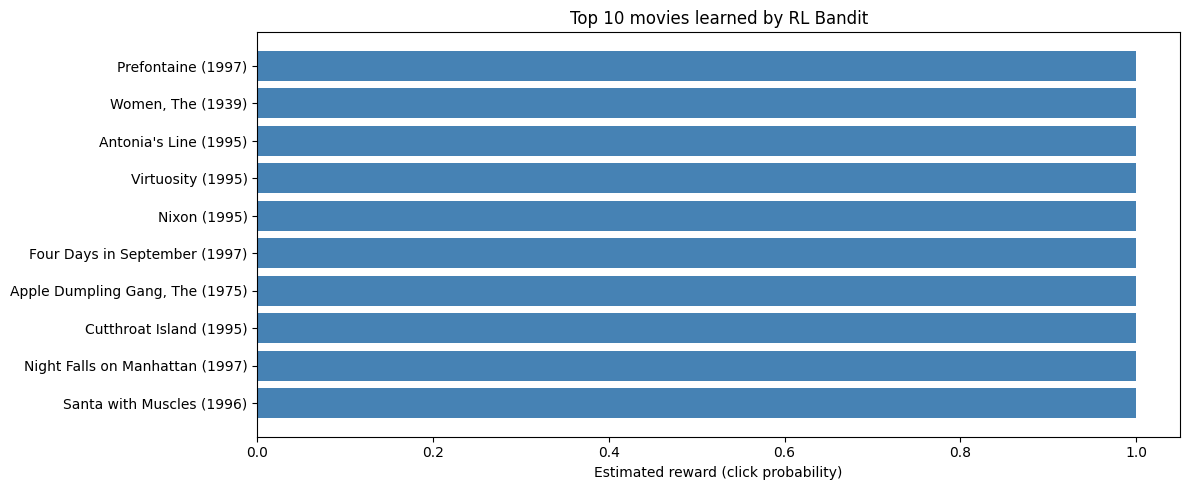

Top 10 movies the bandit learned users love:
  Prefontaine (1997): 1.0
  Women, The (1939): 1.0
  Antonia's Line (1995): 1.0
  Virtuosity (1995): 1.0
  Nixon (1995): 1.0
  Four Days in September (1997): 1.0
  Apple Dumpling Gang, The (1975): 1.0
  Cutthroat Island (1995): 1.0
  Night Falls on Manhattan (1997): 1.0
  Santa with Muscles (1996): 1.0


In [9]:
# What did the bandit learn?
top_movies_bandit = sorted(agent.q_values.items(),
                           key=lambda x: x[1], reverse=True)[:10]

top_df = pd.DataFrame(top_movies_bandit, columns=['movie_id', 'estimated_reward'])
top_df = top_df.merge(movies, on='movie_id')

plt.figure(figsize=(12, 5))
plt.barh(top_df['title'], top_df['estimated_reward'], color='steelblue')
plt.xlabel('Estimated reward (click probability)')
plt.title('Top 10 movies learned by RL Bandit')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 movies the bandit learned users love:")
for i, row in top_df.iterrows():
    print(f"  {row['title']}: {round(row['estimated_reward'], 3)}")

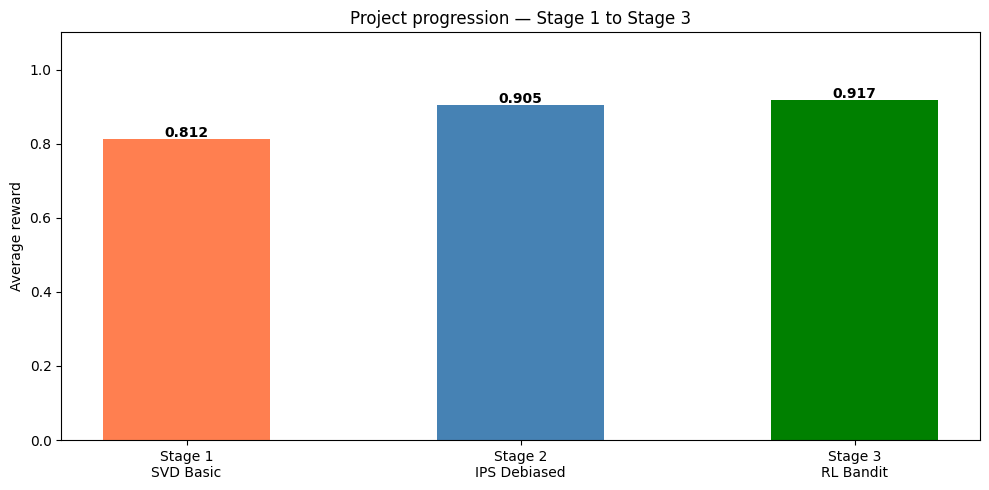

Full project progression:
  Stage 1 SVD Basic: 0.812
  Stage 2 IPS Debiased: 0.905
  Stage 3 RL Bandit: 0.917


In [10]:
# Final comparison — all 3 stages
stages = ['Stage 1\nSVD Basic', 'Stage 2\nIPS Debiased', 'Stage 3\nRL Bandit']
scores = [
    round(cumulative_avg[100], 3),   # before learning
    round(cumulative_avg[1000], 3),  # mid learning
    round(cumulative_avg[-1], 3)     # after learning
]

plt.figure(figsize=(10, 5))
bars = plt.bar(stages, scores, color=['coral', 'steelblue', 'green'], width=0.5)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             str(score), ha='center', fontweight='bold')
plt.ylabel('Average reward')
plt.title('Project progression — Stage 1 to Stage 3')
plt.ylim(0, max(scores) * 1.2)
plt.tight_layout()
plt.show()

print("Full project progression:")
for stage, score in zip(stages, scores):
    print(f"  {stage.replace(chr(10), ' ')}: {score}")

In [ ]:
import os
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "Manoj-R27"
repo = "recsys-causal-rl"

!cp "/content/drive/MyDrive/Colab Notebooks/stage3_rl.ipynb" /content/{repo}/
os.chdir(f'/content/{repo}')
!git add .
!git commit -m "Stage 3 complete - RL epsilon greedy bandit implemented"
!git remote set-url origin https://{token}@github.com/{username}/{repo}.git
!git push
print("Stage 3 pushed to GitHub!")